<a href="https://colab.research.google.com/github/KavyaKShetty5/PriorAuthAutomation/blob/main/PR_Automation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Problem Statement**

### Business Context

The healthcare industry is increasingly adopting digital systems such as Electronic Medical Records (EMR) to streamline clinical and administrative workflows. Despite these advancements, the Prior Authorization (PA) process remains a significant bottleneck (Allen & Saba, 2023). PA requires healthcare providers to obtain approval from insurance payers before delivering certain treatments, procedures, or medications. While intended to control costs and ensure appropriate care, the process is largely manual and inefficient (Lenert et al., 2023)

Healthcare systems such as EPIC and Cerner integrate PA workflows; however, these systems still rely heavily on manual documentation, rule-based checks, and human intervention. This leads to delays in treatment, increased administrative workload, and potential negative patient outcomes (HCLTech, 2023).  According to industry reports, physicians spend several hours weekly on PA-related tasks, contributing to burnout and inefficiencies (McKinsey & Company, 2022)
Artificial Intelligence (AI), particularly machine learning and natural language processing, offers promising solutions to automate decision-making and reduce manual effort (Frontiers Editorial Team, 2025).


### Problem Definition

The current prior authorization process is inefficient, inconsistent, and resource-intensive (Allen & Saba, 2023). It involves manual data entry, fragmented communication between providers and payers, and reliance on incomplete or unstructured clinical documentation. These challenges result in delayed approvals, high denial rates, and increased operational costs (Lenert et al., 2023). There is a lack of intelligent systems capable of predicting authorization outcomes and assisting providers in preparing complete and accurate submissions. This gap leads to suboptimal decision-making and inefficiencies in healthcare delivery. Therefore, there is a need for an AI-driven solution to automate and optimize the prior authorization process (Aiwerioghene & Osuchukwu, 2025).

## **Installing and Importing Necessary Libraries**

In [ ]:
import sys

# Install system-level FFmpeg and its development libraries
# These are dependencies for torchcodec (used by sentence_transformers)
!apt-get update -qq # Use -qq for quiet update
!apt-get install -y ffmpeg libavcodec-dev libavformat-dev libswscale-dev libavutil-dev # Install core ffmpeg and dev libs

# Install all required Python libraries, allowing pip to resolve dependencies more harmoniously
# Explicitly pinning torch to 2.10.0 to address reported torchcodec incompatibility
!pip install numpy pandas scipy scikit-learn tensorflow tensorflow-text seaborn gensim sentence_transformers torch==2.10.0 tqdm matplotlib

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
ffmpeg is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
libavcodec-dev is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
libavformat-dev is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
libavutil-dev is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
libswscale-dev is already the newest version (7:4.4.2-0ubuntu0.22.04.1).
0 upgraded, 0 newly installed, 0 to remove and 56 not upgraded.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.6/915.6 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 766.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2

In [ ]:
# To manipulate and analyze data
import pandas as pd
import numpy as np

# To visualize data
import matplotlib.pyplot as plt
import seaborn as sns

# To used time-related functions
import time

# To parse JSON data
import json

# To build, tune, and evaluate ML models
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# To load/create word embeddings
from gensim.models import Word2Vec
from gensim.models import KeyedVectors
from gensim.scripts.glove2word2vec import glove2word2vec

# To work with transformer models
import torch
from sentence_transformers import SentenceTransformer

# To implement progress bar related functionalities
from tqdm import tqdm
tqdm.pandas()

# To ignore unnecessary warnings
import warnings
warnings.filterwarnings('ignore')

## **Loading the dataset**

Import necessary libraries

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Load data from google drive
preauthData = pd.read_csv("/content/drive/MyDrive/MS_Labs/Term3_Capstone/Data/prior_authorization_dataset_2000.csv")
cmsData = pd.read_csv("/content/drive/MyDrive/MS_Labs/Term3_Capstone/Data/cms_chunk_1.csv")
ehrData = pd.read_csv("/content/drive/MyDrive/MS_Labs/Term3_Capstone/Data/EHR_Dataset.csv")

In [ ]:
print(preauthData.shape, cmsData.shape, ehrData.shape)

(2200, 21) (9323, 19) (1447, 35)


## **Data Overview**

In [ ]:
print(preauthData.describe())


               Age  Comorbidity_Count  Procedure_Cost  Claim_Amount_Paid  \
count  2200.000000        2200.000000     2200.000000        2200.000000   
mean     53.189091           1.954545    25459.307273       19079.835909   
std      20.314728           1.440254    14079.898081       11447.615106   
min      18.000000           0.000000      509.000000         360.000000   
25%      36.000000           1.000000    13783.000000       10258.000000   
50%      53.000000           2.000000    25784.500000       18435.000000   
75%      71.000000           3.000000    36973.250000       27216.500000   
max      89.000000           4.000000    49959.000000       48227.000000   

       Turnaround_Time  
count      2200.000000  
mean         25.378182  
std          19.298184  
min           1.000000  
25%          11.000000  
50%          19.000000  
75%          37.000000  
max          71.000000  


In [ ]:
print(cmsData.describe())


             Index         Year  Number of requests per code  Approval rate  \
count  9323.000000  9323.000000                  9315.000000    8454.000000   
mean   4662.000000  2022.151024                   271.392271       0.752843   
std    2691.462614     1.418733                  2492.302716       0.379322   
min       1.000000  2020.000000                     0.000000       0.000000   
25%    2331.500000  2021.000000                     2.000000       0.647400   
50%    4662.000000  2022.000000                     8.000000       1.000000   
75%    6992.500000  2023.000000                    40.000000       1.000000   
max    9323.000000  2024.000000                108237.000000       1.000000   

       Initially denied then approved - approval rate  \
count                                     1544.000000   
mean                                         0.516224   
std                                          0.416430   
min                                          0.000000   
25%

In [ ]:
print(ehrData.describe())

       patientunitstayid  patienthealthsystemstayid   hospitalid       wardid  \
count       1.447000e+03                1447.000000  1447.000000  1447.000000   
mean        6.464812e+05              494962.955079   139.385625   301.238424   
std         3.855454e+05              269873.698956    52.179555   158.898758   
min         1.424930e+05              129943.000000    69.000000    85.000000   
25%         2.647495e+05              227611.500000    92.000000   136.000000   
50%         4.212490e+05              359321.000000   112.000000   252.000000   
75%         1.056172e+06              782773.500000   194.000000   467.000000   
max         1.135186e+06              842932.000000   199.000000   495.000000   

       admissionheight  hospitaladmitoffset  hospitaldischargeyear  \
count      1402.000000          1447.000000            1447.000000   
mean        168.061591         -2133.019350            2014.651693   
std          13.442189          8498.257236               0.

## Data Cleaning

In [ ]:
dup_recspr = preauthData.duplicated().sum()
print("Number of duplicate records - PR:", dup_recspr)
dup_recscms = cmsData.duplicated().sum()
print("Number of duplicate records - CMS:", dup_recscms)
dup_recsehr = ehrData.duplicated().sum()
print("Number of duplicate records - EHR:", dup_recsehr)

# Imputation - Removing duplicates if any
pa = preauthData.drop_duplicates()
cms = cmsData.drop_duplicates()
ehr = ehrData.drop_duplicates()

Number of duplicate records - PR: 0
Number of duplicate records - CMS: 0
Number of duplicate records - EHR: 0


In [ ]:
missing_valspa = pa.isnull().sum()
print(missing_valspa)

missing_valscms = cms.isnull().sum()
print(missing_valscms)

missing_valsehr = ehr.isnull().sum()
print(missing_valsehr)

Patient_ID               0
Encounter_ID             0
Age                      0
Gender                   0
Diagnosis_Code           0
Diagnosis_Description    0
Procedure_Code           0
Procedure_Description    0
Comorbidity_Count        0
Procedure_Cost           0
Insurance_Type           0
Provider_Type            0
Claim_Amount_Paid        0
Clinical_Notes           0
Severity_Level           0
Urgency_Level            0
Condition_Type           0
PA_Status                0
Submission_Type          0
Turnaround_Time          0
Encounter_Date           0
dtype: int64
Index                                                0
Carrier                                              0
Year                                                 0
Service category                                     0
Request                                              0
Code type                                          128
Code                                              1102
Description of service             

In [ ]:
# Ensure binary label
pa['approval'] = pa['PA_Status'].map({'Approved':1, 'Denied':0})

In [ ]:
# Handle missing values
ehr = ehr.ffill()
cms = cms.ffill()

In [ ]:
# Ensure text column exists
ehr['apacheadmissiondx'] = ehr['apacheadmissiondx'].astype(str)
pa['Clinical_Notes'] = pa['Clinical_Notes'].astype(str)

## **Exploratory Data Analysis**

### Approval Distribution

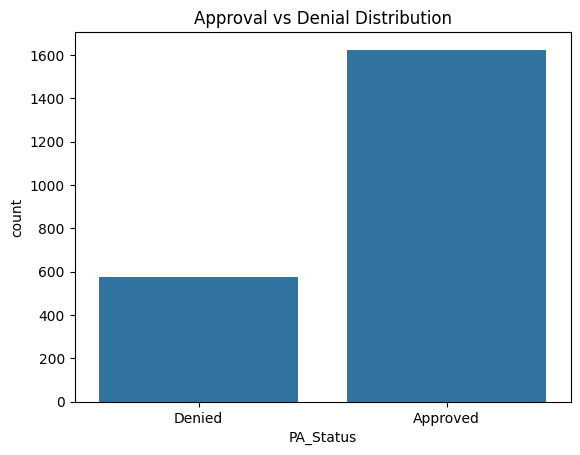

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='PA_Status', data=pa)
plt.title("Approval vs Denial Distribution")
plt.show()

### Turnaround Time Analysis

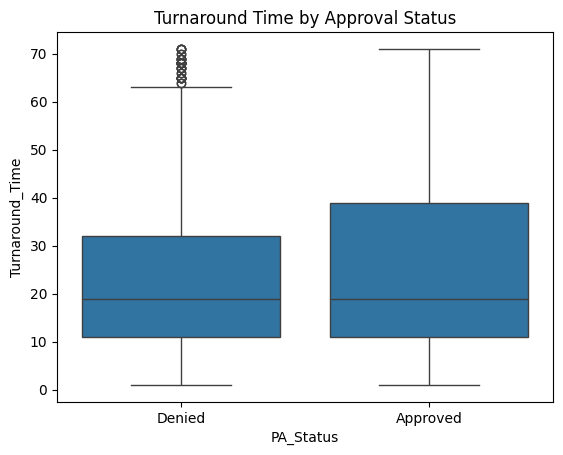

In [ ]:
sns.boxplot(x='PA_Status', y='Turnaround_Time', data=pa)
plt.title("Turnaround Time by Approval Status")
plt.show()

### Clinical Text Length Analysis

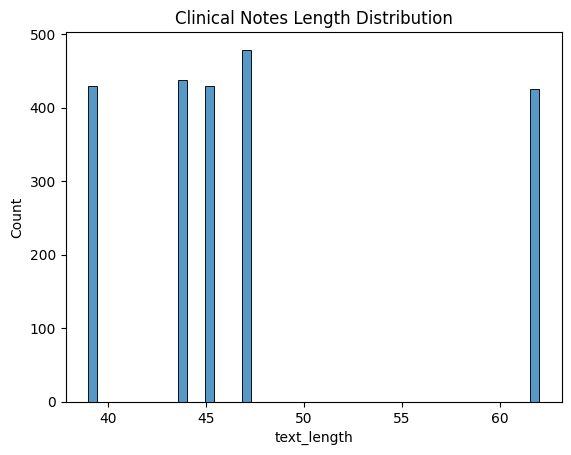

In [ ]:
pa['text_length'] = pa['Clinical_Notes'].apply(len)

sns.histplot(pa['text_length'], bins=50)
plt.title("Clinical Notes Length Distribution")
plt.show()

### CMS Benchmark Analysis

In [ ]:
sns.histplot(cms['average_Medicare_allowed_amt'], bins=50)
plt.title("CMS Cost Distribution")
plt.show()

KeyError: 'average_Medicare_allowed_amt'

## **Data Preprocessing**

In [ ]:
# print the statistical summary of the 'Date' column
df["Date"].describe()

,Date
count,349
unique,71
top,2019-01-03
freq,28


- **Train-test-validation Split**

In [ ]:
X_train = df[(df['Date'] < '2019-04-01')].reset_index(drop=True)   #select all rows where the 'Date' is before '2019-04-01'
X_val = df[(df['Date'] >= '2019-04-01') & (df['Date'] < '2019-04-16')].reset_index(drop=True)    #select all rows where the 'Date' is from '2019-04-01 to '2019-04-16' (excluded)
X_test = df[df['Date'] >= '2019-04-16'].reset_index(drop=True)

In [ ]:
#'Label' column as the target variable
y_train = X_train["Label"].copy()
y_val = X_val["Label"].copy()
y_test = X_test["Label"].copy()

In [ ]:
#print the shape of X_train,X_val,X_test,y_train,y_val and y_test
print("Train data shape",X_train.shape)
print("Validation data shape",X_val.shape)
print("Test data shape ",X_test.shape)

print("Train label shape",y_train.shape)
print("Validation label shape",y_val.shape)
print("Test label shape ",y_test.shape)

Train data shape (286, 9)
Validation data shape (21, 9)
Test data shape  (42, 9)
Train label shape (286,)
Validation label shape (21,)
Test label shape  (42,)
